# Focal + SAT on Long-Tailed CIFAR-10 (Baseline Architecture)

This notebook combines:
- **Baseline SAT architecture**: VGG-16 with Dropout, exact training settings
- **Focal Loss technique**: Re-weights samples via (1-p_t)^gamma
- **Effective Number weighting**: Class-balanced α weights

**Key difference from SAT baseline**: Only the loss function (Focal+SAT instead of pure SAT)

## 1. Setup and Imports

In [1]:
import os
import time
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.backends.cudnn as cudnn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from PIL import Image

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# ============================================================================
# UTILITY CLASSES (From SAT Baseline)
# ============================================================================

class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


def accuracy(output, target, topk=(1,)):
    """Computes the precision@k for the specified values of k"""
    maxk = max(topk)
    batch_size = target.size(0)

    _, pred = output.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))

    res = []
    for k in topk:
        correct_k = correct[:k].reshape(-1).float().sum(0)
        res.append(correct_k.mul_(100.0 / batch_size))
    return res


# ============================================================================
# FOCAL + SAT COMBINED LOSS (From FocalSAT)
# ============================================================================

class FocalSATLoss():
    """Combines Focal Loss re-weighting with SAT label smoothing.
    
    Focal: Down-weights easy examples via (1-p_t)^gamma
    SAT: Smooths labels via momentum-based probability history
    """
    def __init__(self, num_examples=50000, num_classes=10, 
                 gamma=2.0, alpha=None, mom=0.9):
        self.gamma = gamma
        self.alpha = alpha  # Class weights (from effective number)
        self.mom = mom
        self.num_classes = num_classes
        
        # SAT probability history
        self.prob_history = torch.zeros(num_examples, num_classes)
        self.updated = torch.zeros(num_examples, dtype=torch.int)
    
    def _update_prob(self, prob, index, y):
        onehot = torch.zeros_like(prob)
        onehot[torch.arange(y.shape[0]), y] = 1
        
        # Move indices to CPU to avoid CUDA indexing issues
        index_cpu = index.cpu() if index.is_cuda else index
        prob_history = self.prob_history[index_cpu].clone().to(prob.device)

        # if not inited, use onehot label to initialize running vector
        cond = (self.updated[index_cpu] == 1).to(prob.device).unsqueeze(-1).expand_as(prob)
        prob_mom = torch.where(cond, prob_history, onehot)

        # momentum update
        prob_mom = self.mom * prob_mom + (1 - self.mom) * prob

        self.updated[index_cpu] = 1
        self.prob_history[index_cpu] = prob_mom.to(self.prob_history.device)

        return prob_mom

    def __call__(self, logits, y, index):
        prob = F.softmax(logits.detach()[:, :self.num_classes], dim=1)
        prob = self._update_prob(prob, index, y)
        
        # Focal weighting: (1 - p_t)^gamma
        p_t = prob[torch.arange(y.shape[0]), y]  # Probability of true class
        focal_weight = (1 - p_t) ** self.gamma
        
        # SAT soft label
        soft_label = torch.zeros_like(logits)
        soft_label[torch.arange(y.shape[0]), y] = prob[torch.arange(y.shape[0]), y]
        soft_label[:, -1] = 1 - prob[torch.arange(y.shape[0]), y]
        soft_label = F.normalize(soft_label, dim=1, p=1)
        
        # Cross-entropy with soft labels
        loss = torch.sum(-F.log_softmax(logits, dim=1) * soft_label, dim=1)
        
        # Apply focal weighting
        focal_loss = focal_weight * loss
        
        # Apply class weights if provided
        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device)[y]
            focal_loss = alpha_t * focal_loss
        
        return torch.mean(focal_loss)


# ============================================================================
# VGG-16 MODEL (From SAT Baseline - With Dropout)
# ============================================================================

class VGG(nn.Module):
    def __init__(self, features, num_classes=1000, input_size=32):
        super(VGG, self).__init__()
        self.features = features
        if input_size == 32:
            self.classifier = nn.Sequential(
                nn.Linear(512, 512), nn.ReLU(inplace=True),
                nn.BatchNorm1d(512), nn.Dropout2d(0.5),
                nn.Linear(512, num_classes)
            )
        elif input_size == 64:
            self.classifier = nn.Sequential(
                nn.Linear(2048, 512), nn.ReLU(inplace=True),
                nn.BatchNorm1d(512), nn.Dropout2d(0.5),
                nn.Linear(512, num_classes)
            )
        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                n = m.weight.size(1)
                m.weight.data.normal_(0, 0.01)
                m.bias.data.zero_()


def make_layers(cfg, batch_norm=False):
    layers = []
    in_channels = 3
    for v in cfg:
        if v == 'M':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        elif type(v) == int:
            conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
            if batch_norm:
                layers += [conv2d, nn.ReLU(inplace=True), nn.BatchNorm2d(v)]
            else:
                layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = v
        elif type(v) == float:
            layers += [nn.Dropout2d(v)]
    return nn.Sequential(*layers)


cfg_vgg16 = {
    'D': [64, 0.3, 64, 'M', 128, 0.4, 128, 'M', 256, 0.4, 256, 0.4, 256, 'M',
          512, 0.4, 512, 0.4, 512, 'M', 512, 0.4, 512, 0.4, 512, 'M', 0.5]
}


def vgg16_bn(num_classes=1000, input_size=32, **kwargs):
    """VGG 16-layer model with batch normalization (from SAT baseline)"""
    model = VGG(make_layers(cfg_vgg16['D'], batch_norm=True), 
                num_classes=num_classes, input_size=input_size, **kwargs)
    return model


print("✅ All utility classes, Focal+SAT loss, and VGG-16 model embedded!")
print("🎯 Baseline SAT architecture with Focal Loss technique!")

PyTorch version: 2.0.1+cu117
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3060
✅ All utility classes, Focal+SAT loss, and VGG-16 model embedded!
🎯 Baseline SAT architecture with Focal Loss technique!


## 2. Configuration

In [2]:
# Configuration (Matching SAT Baseline EXACTLY)
class Config:
    # Dataset settings
    dataset = 'cifar10'
    imbalance_ratio = 100
    
    # Architecture
    arch = 'vgg16_bn'
    
    # Training settings (SAME AS SAT BASELINE)
    loss_type = 'focal_sat'
    epochs = 300
    pretrain_epochs = 0
    
    # Focal Loss parameters
    focal_gamma = 2.0
    effective_beta = 0.9999
    
    # Hyperparameters (SAME AS SAT BASELINE)
    batch_size_train = 128
    batch_size_test = 200
    lr = 0.1
    momentum = 0.9
    sat_momentum = 0.99
    weight_decay = 5e-4
    gamma = 0.5
    schedule = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275]
    
    # System settings
    gpu_id = '0'
    num_workers = 4
    manual_seed = 42
    save_dir = f'./checkpoints/focalsat_baseline_ir{100}'
    
config = Config()

# ============================================================================
# Reproducibility Settings (SAME AS SAT BASELINE)
# ============================================================================

random.seed(config.manual_seed)
torch.manual_seed(config.manual_seed)
np.random.seed(config.manual_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.manual_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception as e:
    print(f"Warning: torch.use_deterministic_algorithms not available: {e}")

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

os.environ['CUDA_VISIBLE_DEVICES'] = config.gpu_id
use_cuda = torch.cuda.is_available()
os.makedirs(config.save_dir, exist_ok=True)

print("🔒 Configuration (Matching SAT Baseline):")
print(f"  Dataset: CIFAR-10 Long-Tailed (IR={config.imbalance_ratio})")
print(f"  Architecture: {config.arch} (with Dropout)")
print(f"  Loss: Focal(γ={config.focal_gamma}) + SAT(momentum={config.sat_momentum})")
print(f"  Epochs: {config.epochs}")
print(f"  Save dir: {config.save_dir}")

🔒 Configuration (Matching SAT Baseline):
  Dataset: CIFAR-10 Long-Tailed (IR=100)
  Architecture: vgg16_bn (with Dropout)
  Loss: Focal(γ=2.0) + SAT(momentum=0.99)
  Epochs: 300
  Save dir: ./checkpoints/focalsat_baseline_ir100


## 3. Dataset Preparation (100% From SAT Baseline)

Creating Long-Tailed CIFAR-10 programmatically (IR=100)...
Files already downloaded and verified
Files already downloaded and verified
Creating long-tailed distribution (matching cifar10-lt.py methodology)...
Imbalance ratio: 1:100
Random seed: 0 (for reproducibility)
Target samples per class: [5000, 2997, 1796, 1077, 645, 387, 232, 139, 83, 50]
Total selected training samples: 12406
✅ Dataset creation matches cifar10-lt.py exactly!

✅ Dataset created successfully!
Training samples: 12406 (imbalanced)
Test samples: 10000 (balanced)
Number of classes: 10


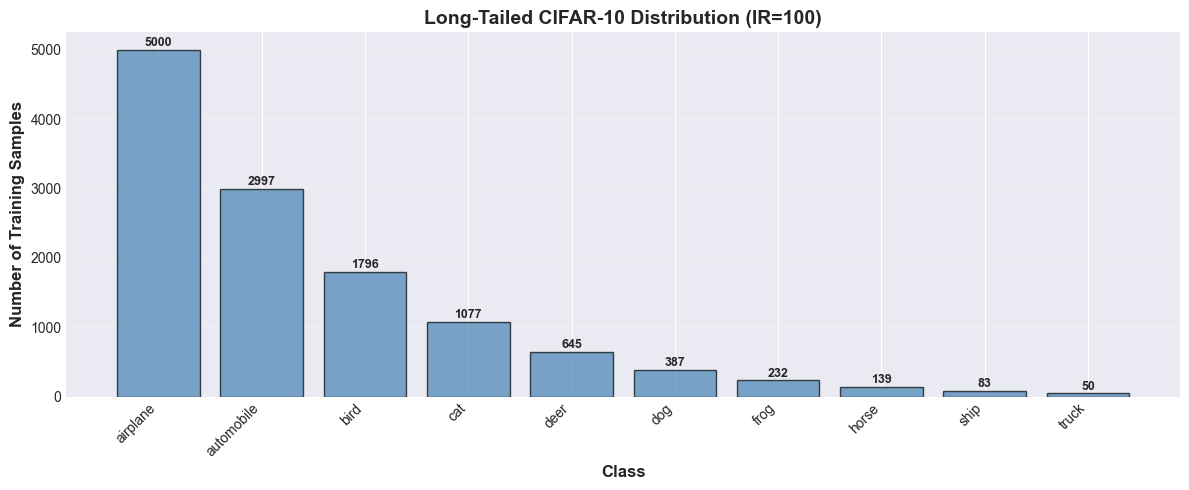


Calculating class weights using Effective Number (beta=0.9999)...
Class weights (Effective Number): [0.05061136 0.0768998  0.12113387 0.19503666 0.31880537 0.52458984
 0.86834896 1.4426273  2.409223   3.9927237 ]
Weight ratio (max/min): 78.89


In [3]:
import torchvision.datasets as tv_datasets

print(f'Creating Long-Tailed CIFAR-10 programmatically (IR={config.imbalance_ratio})...')

num_classes = 10
input_size = 32

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

print("Downloading CIFAR-10 dataset...")
base_trainset = tv_datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
base_testset = tv_datasets.CIFAR10(root='./data', train=False, download=True, transform=None)

print(f"Creating long-tailed distribution (matching cifar10-lt.py methodology)...")
print(f"Imbalance ratio: 1:{config.imbalance_ratio}")

RAND_SEED = 0
np.random.seed(RAND_SEED)
print(f"Random seed: {RAND_SEED} (for reproducibility)")

all_labels = []
for idx in range(len(base_trainset)):
    _, label = base_trainset[idx]
    all_labels.append(label)
targets_np = np.array(all_labels, dtype=np.int64)

img_max = len(base_trainset) / num_classes
imb_factor = 1.0 / config.imbalance_ratio

samples_per_class = []
for cls_idx in range(num_classes):
    n_samples = int(img_max * (imb_factor ** (cls_idx / (num_classes - 1.0))))
    samples_per_class.append(n_samples)

print(f"Target samples per class: {samples_per_class}")

selected_train_indices = []
for cls_idx in range(num_classes):
    idx = np.where(targets_np == cls_idx)[0]
    np.random.shuffle(idx)
    n_samples = samples_per_class[cls_idx]
    selected_idx = idx[:n_samples]
    selected_train_indices.extend(selected_idx.tolist())

print(f"Total selected training samples: {len(selected_train_indices)}")
print(f"✅ Dataset creation matches cifar10-lt.py exactly!")

class ImbalancedSubset(Subset):
    def __getitem__(self, idx):
        img, target = self.dataset[self.indices[idx]]
        return img, target, idx

trainset_subset = ImbalancedSubset(base_trainset, selected_train_indices)
testset_subset = ImbalancedSubset(base_testset, list(range(len(base_testset))))

class TransformWrapper(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.targets = []
        for idx in range(len(subset)):
            _, target, _ = subset[idx]
            self.targets.append(target)
        self.targets = np.array(self.targets)
    
    def __len__(self):
        return len(self.subset)
    
    def __getitem__(self, idx):
        img, target, original_idx = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, target, idx
    
    def get_class_distribution(self):
        unique, counts = np.unique(self.targets, return_counts=True)
        return dict(zip(unique, counts))

trainset = TransformWrapper(trainset_subset, transform=transform_train)
testset = TransformWrapper(testset_subset, transform=transform_test)

train_generator = torch.Generator().manual_seed(config.manual_seed)
test_generator = torch.Generator().manual_seed(config.manual_seed)

trainloader = DataLoader(
    trainset, 
    batch_size=config.batch_size_train, 
    shuffle=True, 
    num_workers=config.num_workers,
    worker_init_fn=seed_worker,
    generator=train_generator
)

testloader = DataLoader(
    testset, 
    batch_size=config.batch_size_test, 
    shuffle=False, 
    num_workers=config.num_workers,
    worker_init_fn=seed_worker,
    generator=test_generator
)

print(f"\n✅ Dataset created successfully!")
print(f"Training samples: {len(trainset)} (imbalanced)")
print(f"Test samples: {len(testset)} (balanced)")
print(f"Number of classes: {num_classes}")

train_dist = trainset.get_class_distribution()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(num_classes), [train_dist[i] for i in range(num_classes)], alpha=0.7, color='steelblue', edgecolor='black')
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Training Samples', fontweight='bold', fontsize=12)
ax.set_title(f'Long-Tailed CIFAR-10 Distribution (IR={config.imbalance_ratio})', fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

for i, count in enumerate(samples_per_class):
    ax.text(i, count + 50, str(count), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'dataset_distribution.png'), dpi=150)
plt.show()

# Calculate Class Weights using Effective Number
print(f"\nCalculating class weights using Effective Number (beta={config.effective_beta})...")

effective_num = 1.0 - np.power(config.effective_beta, np.array(samples_per_class))
weights = (1.0 - config.effective_beta) / effective_num
weights = weights / weights.sum() * num_classes

class_weights = torch.FloatTensor(weights)
print(f"Class weights (Effective Number): {class_weights.numpy()}")
print(f"Weight ratio (max/min): {weights.max() / weights.min():.2f}")

## 4. Model Setup

In [4]:
print(f"Creating model: {config.arch}")

model_num_classes = num_classes + 1  # Extra dimension for abstention
model = vgg16_bn(num_classes=model_num_classes, input_size=input_size)

if use_cuda:
    model = torch.nn.DataParallel(model.cuda())

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params/1e6:.2f}M")

# Setup Focal+SAT loss with class-balanced weights
criterion = FocalSATLoss(
    num_examples=len(trainset),
    num_classes=num_classes,
    gamma=config.focal_gamma,
    alpha=class_weights,
    mom=config.sat_momentum
)

optimizer = optim.SGD(model.parameters(), lr=config.lr, 
                     momentum=config.momentum, weight_decay=config.weight_decay)

print(f"Loss: Focal(γ={config.focal_gamma}) + SAT(mom={config.sat_momentum})")
print(f"Optimizer: SGD (lr={config.lr}, momentum={config.momentum})")

Creating model: vgg16_bn
Total parameters: 14.99M
Loss: Focal(γ=2.0) + SAT(mom=0.99)
Optimizer: SGD (lr=0.1, momentum=0.9)


## 5. Training Functions (From SAT Baseline)

In [5]:
def train_epoch(trainloader, model, criterion, optimizer, epoch, use_cuda, config):
    model.train()
    
    losses = AverageMeter()
    top1 = AverageMeter()
    
    class_correct = np.zeros(num_classes)
    class_total = np.zeros(num_classes)
    
    for batch_idx, batch_data in enumerate(trainloader):
        inputs, targets, indices = batch_data
        
        if use_cuda:
            inputs, targets = inputs.cuda(), targets.cuda()
        
        outputs = model(inputs)
        
        if epoch >= config.pretrain_epochs:
            loss = criterion(outputs, targets, indices)
        else:
            loss = F.cross_entropy(outputs[:, :-1], targets)
        
        prec1 = accuracy(outputs.data, targets.data, topk=(1,))[0]
        losses.update(loss.item(), inputs.size(0))
        top1.update(prec1.item(), inputs.size(0))
        
        _, predicted = outputs[:, :-1].max(1)
        for i in range(num_classes):
            mask = targets == i
            if mask.sum() > 0:
                class_correct[i] += (predicted[mask] == targets[mask]).sum().item()
                class_total[i] += mask.sum().item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    class_acc = []
    for i in range(num_classes):
        if class_total[i] > 0:
            class_acc.append(100.0 * class_correct[i] / class_total[i])
        else:
            class_acc.append(0.0)
    
    balanced_acc = np.mean(class_acc)
    worst_acc = np.min(class_acc)
    
    return losses.avg, top1.avg, balanced_acc, worst_acc

def test_epoch(testloader, model, criterion, epoch, use_cuda, config):
    model.eval()
    
    losses = AverageMeter()
    top1 = AverageMeter()
    
    class_correct = np.zeros(num_classes)
    class_total = np.zeros(num_classes)
    
    with torch.no_grad():
        for batch_idx, batch_data in enumerate(testloader):
            inputs, targets, indices = batch_data
            
            if use_cuda:
                inputs = inputs.cuda()
            
            outputs = model(inputs).cpu()
            
            if epoch >= config.pretrain_epochs:
                loss = F.cross_entropy(outputs[:, :-1], targets)
                _, predictions = outputs[:, :-1].max(1)
            else:
                loss = F.cross_entropy(outputs[:, :-1], targets)
                _, predictions = outputs[:, :-1].max(1)
            
            prec1 = accuracy(outputs[:, :-1].data, targets.data, topk=(1,))[0]
            losses.update(loss.item(), inputs.size(0))
            top1.update(prec1.item(), inputs.size(0))
            
            correct = predictions == targets
            for i in range(num_classes):
                mask = targets == i
                if mask.sum() > 0:
                    class_correct[i] += correct[mask].sum().item()
                    class_total[i] += mask.sum().item()
    
    class_acc = []
    for i in range(num_classes):
        if class_total[i] > 0:
            class_acc.append(100.0 * class_correct[i] / class_total[i])
        else:
            class_acc.append(0.0)
    
    balanced_acc = np.mean(class_acc)
    worst_acc = np.min(class_acc)
    
    return losses.avg, top1.avg, balanced_acc, worst_acc, class_acc

print("Training and evaluation functions defined.")

Training and evaluation functions defined.


## 6. Training Loop

In [6]:
history = {
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'train_balanced_acc': [],
    'train_worst_acc': [],
    'test_loss': [],
    'test_acc': [],
    'test_balanced_acc': [],
    'test_worst_acc': [],
    'test_class_acc': []
}

print(f"Starting training for {config.epochs} epochs...")
print("=" * 100)
print(f"{'Epoch':>5} | {'LR':>10} | {'Train Acc':>10} | {'Bal Acc':>10} | {'Worst Acc':>10} | {'Test Acc':>10} | {'Bal Acc':>10} | {'Worst Acc':>10} | {'Time':>6} | {'Status'}")
print("=" * 100)

best_balanced_acc = 0.0
best_worst_acc = 0.0
start_time = time.time()

for epoch in range(config.epochs):
    epoch_start = time.time()
    
    # Adjust learning rate
    if epoch in config.schedule:
        config.lr *= config.gamma
        for param_group in optimizer.param_groups:
            param_group['lr'] = config.lr
    
    # Train
    train_loss, train_acc, train_bal_acc, train_worst_acc = train_epoch(
        trainloader, model, criterion, optimizer, epoch, use_cuda, config
    )
    
    # Test
    test_loss, test_acc, test_bal_acc, test_worst_acc, test_class_acc = test_epoch(
        testloader, model, criterion, epoch, use_cuda, config
    )
    
    # Save history
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_balanced_acc'].append(train_bal_acc)
    history['train_worst_acc'].append(train_worst_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['test_balanced_acc'].append(test_bal_acc)
    history['test_worst_acc'].append(test_worst_acc)
    history['test_class_acc'].append(test_class_acc)
    
    epoch_time = time.time() - epoch_start
    
    # Track best models
    status = ""
    if test_bal_acc > best_balanced_acc:
        best_balanced_acc = test_bal_acc
        checkpoint_path = os.path.join(config.save_dir, 'best_balanced_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'balanced_acc': best_balanced_acc,
        }, checkpoint_path)
        status += "*BAL* "
    
    if test_worst_acc > best_worst_acc:
        best_worst_acc = test_worst_acc
        checkpoint_path = os.path.join(config.save_dir, 'best_worst_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'worst_acc': best_worst_acc,
        }, checkpoint_path)
        status += "*WORST*"
    
    # Compact output
    print(f"{epoch+1:5d} | {config.lr:10.6f} | {train_acc:9.2f}% | {train_bal_acc:9.2f}% | {train_worst_acc:9.2f}% | "
          f"{test_acc:9.2f}% | {test_bal_acc:9.2f}% | {test_worst_acc:9.2f}% | {epoch_time:5.1f}s | {status}")
    
    # Save periodic checkpoint
    if (epoch + 1) % 50 == 0 or (epoch + 1) == config.epochs:
        checkpoint_path = os.path.join(config.save_dir, f'checkpoint_epoch_{epoch+1}.pth')
        torch.save(model, checkpoint_path)

total_time = time.time() - start_time
print("\n" + "=" * 100)
print(f"Training completed in {total_time/3600:.2f} hours")
print(f"Best balanced accuracy: {best_balanced_acc:.2f}%")
print(f"Best worst-group accuracy: {best_worst_acc:.2f}%")
print("=" * 100)

Starting training for 300 epochs...
Epoch |         LR |  Train Acc |    Bal Acc |  Worst Acc |   Test Acc |    Bal Acc |  Worst Acc |   Time | Status


/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/torch/nn/functional.py:1331: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)
/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/torch/autograd/__init__.py:200: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8

    1 |   0.100000 |      8.60% |     10.49% |      7.84% |      9.56% |      9.56% |      0.00% |   8.0s | *BAL* 
    2 |   0.100000 |      8.57% |      9.60% |      5.04% |      9.13% |      9.13% |      0.00% |   6.9s | 
    3 |   0.100000 |      9.09% |      9.18% |      5.04% |      9.22% |      9.22% |      0.00% |   6.8s | 
    4 |   0.100000 |      8.93% |      9.95% |      6.00% |      9.03% |      9.03% |      0.00% |   6.6s | 
    5 |   0.100000 |      8.97% |     11.47% |      7.80% |      9.53% |      9.53% |      0.00% |   6.4s | 
    6 |   0.100000 |      9.16% |     11.31% |      7.23% |      9.53% |      9.53% |      0.00% |   6.4s | 
    7 |   0.100000 |      9.24% |     10.29% |      8.00% |      9.85% |      9.85% |      0.00% |   6.5s | *BAL* 
    8 |   0.100000 |      9.21% |      8.98% |      4.82% |      9.92% |      9.92% |      0.00% |   6.5s | *BAL* 
    9 |   0.100000 |      9.23% |     10.50% |      4.00% |     10.00% |     10.00% |      0.00% |   6.6s | *B

## 7. Visualization: Training Curves

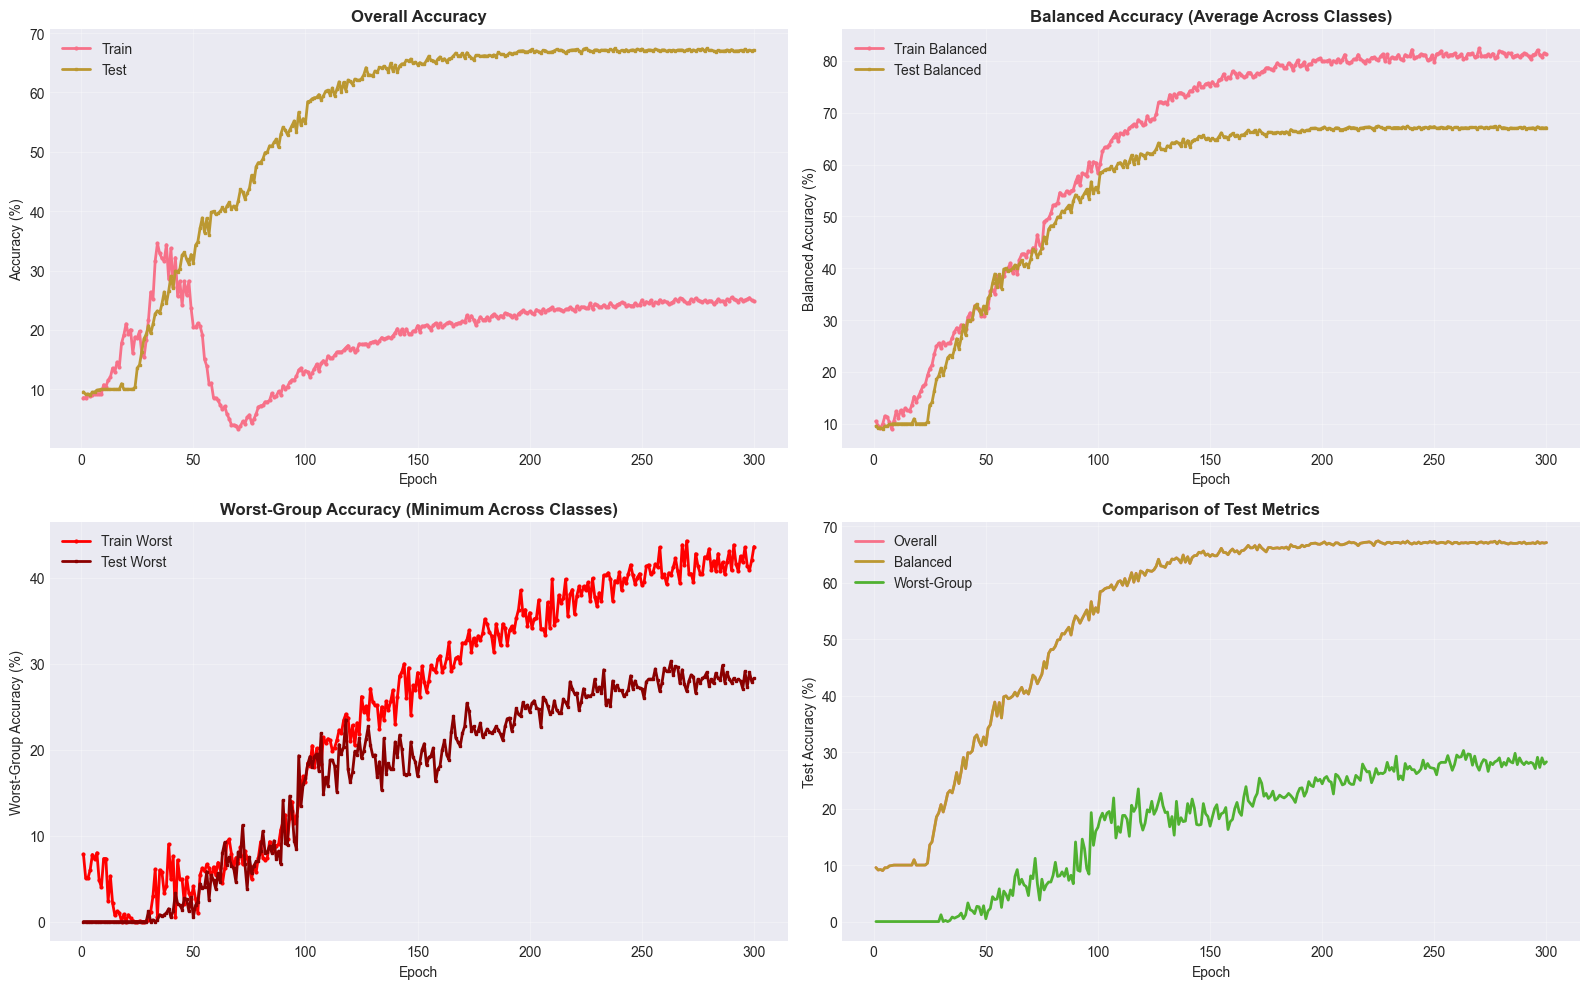

Training curves saved to ./checkpoints/focalsat_baseline_ir100/training_curves.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(history['epoch'], history['train_acc'], label='Train', linewidth=2, marker='o', markersize=2)
ax.plot(history['epoch'], history['test_acc'], label='Test', linewidth=2, marker='s', markersize=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Overall Accuracy', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(history['epoch'], history['train_balanced_acc'], label='Train Balanced', linewidth=2, marker='o', markersize=2)
ax.plot(history['epoch'], history['test_balanced_acc'], label='Test Balanced', linewidth=2, marker='s', markersize=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Balanced Accuracy (%)')
ax.set_title('Balanced Accuracy (Average Across Classes)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(history['epoch'], history['train_worst_acc'], label='Train Worst', linewidth=2, marker='o', markersize=2, color='red')
ax.plot(history['epoch'], history['test_worst_acc'], label='Test Worst', linewidth=2, marker='s', markersize=2, color='darkred')
ax.set_xlabel('Epoch')
ax.set_ylabel('Worst-Group Accuracy (%)')
ax.set_title('Worst-Group Accuracy (Minimum Across Classes)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(history['epoch'], history['test_acc'], label='Overall', linewidth=2)
ax.plot(history['epoch'], history['test_balanced_acc'], label='Balanced', linewidth=2)
ax.plot(history['epoch'], history['test_worst_acc'], label='Worst-Group', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Comparison of Test Metrics', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'training_curves.png'), dpi=150)
plt.show()

print(f"Training curves saved to {config.save_dir}/training_curves.png")

## 8. Per-Class Performance Analysis


Final Per-Class Performance:
        Class  Train Samples  Test Accuracy (%)  Test Error (%)
0    airplane           5000               88.4            11.6
1  automobile           2997               95.7             4.3
2        bird           1796               56.1            43.9
3         cat           1077               28.3            71.7
4        deer            645               77.5            22.5
5         dog            387               72.4            27.6
6        frog            232               81.9            18.1
7       horse            139               61.0            39.0
8        ship             83               60.5            39.5
9       truck             50               49.5            50.5


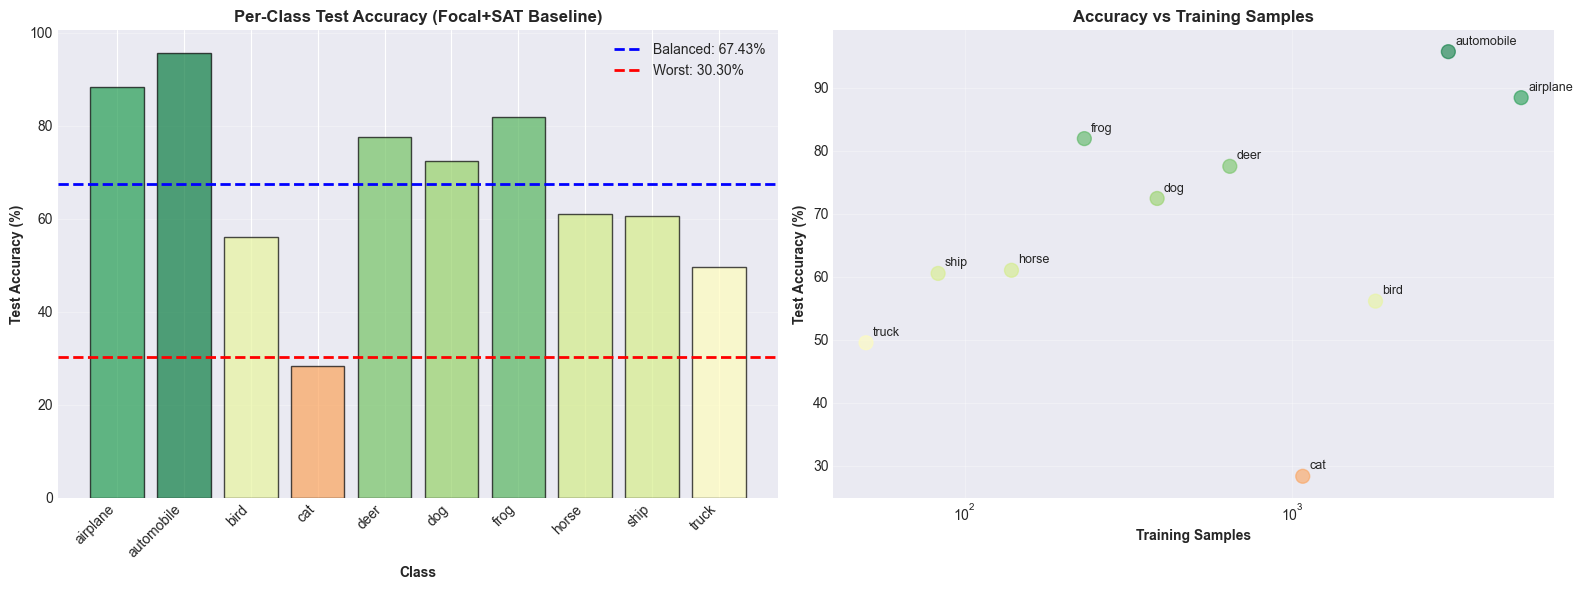


Per-class performance:
  airplane    : 88.40% (5000 samples)
  automobile  : 95.70% (2997 samples)
  bird        : 56.10% (1796 samples)
  cat         : 28.30% (1077 samples)
  deer        : 77.50% ( 645 samples)
  dog         : 72.40% ( 387 samples)
  frog        : 81.90% ( 232 samples)
  horse       : 61.00% ( 139 samples)
  ship        : 60.50% (  83 samples)
  truck       : 49.50% (  50 samples)

Balanced: 67.43%
Worst: 30.30%
Best: 95.70%
Gap: 67.40%


In [8]:
final_class_acc = history['test_class_acc'][-1]

df_class_perf = pd.DataFrame({
    'Class': class_names,
    'Train Samples': [train_dist[i] for i in range(num_classes)],
    'Test Accuracy (%)': final_class_acc,
    'Test Error (%)': [100 - acc for acc in final_class_acc]
})

print("\nFinal Per-Class Performance:")
print(df_class_perf)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
colors = plt.cm.RdYlGn(np.array(final_class_acc) / 100)
bars = ax.bar(range(num_classes), final_class_acc, color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Class', fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontweight='bold')
ax.set_title('Per-Class Test Accuracy (Focal+SAT Baseline)', fontweight='bold')
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.axhline(y=best_balanced_acc, color='blue', linestyle='--', 
           label=f'Balanced: {best_balanced_acc:.2f}%', linewidth=2)
ax.axhline(y=best_worst_acc, color='red', linestyle='--', 
           label=f'Worst: {best_worst_acc:.2f}%', linewidth=2)
ax.legend()
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.scatter([train_dist[i] for i in range(num_classes)], final_class_acc, s=100, alpha=0.6, c=colors)
for i, name in enumerate(class_names):
    ax.annotate(name, (train_dist[i], final_class_acc[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_xlabel('Training Samples', fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontweight='bold')
ax.set_title('Accuracy vs Training Samples', fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'per_class_performance.png'), dpi=150)
plt.show()

print(f"\nPer-class performance:")
for i, (name, acc, samples) in enumerate(zip(class_names, final_class_acc, [train_dist[j] for j in range(num_classes)])):
    print(f"  {name:12s}: {acc:5.2f}% ({samples:4d} samples)")
print(f"\nBalanced: {best_balanced_acc:.2f}%")
print(f"Worst: {best_worst_acc:.2f}%")
print(f"Best: {np.max(final_class_acc):.2f}%")
print(f"Gap: {np.max(final_class_acc) - np.min(final_class_acc):.2f}%")

## 9. Summary Report

In [9]:
print("\n" + "="*80)
print("FOCAL+SAT BASELINE SUMMARY REPORT")
print("="*80)

print(f"\nApproach: Focal Loss (γ={config.focal_gamma}) + SAT (momentum={config.sat_momentum})")
print(f"Dataset: CIFAR-10 Long-Tailed (IR={config.imbalance_ratio})")
print(f"Architecture: {config.arch} (WITH DROPOUT - Same as SAT Baseline)")
print(f"Training: {config.epochs} epochs")

print(f"\nFinal Results:")
print(f"  Balanced Accuracy: {best_balanced_acc:.2f}%")
print(f"  Worst-Group Accuracy: {best_worst_acc:.2f}%")
print(f"  Best-Group Accuracy: {np.max(final_class_acc):.2f}%")
print(f"  Performance Gap: {np.max(final_class_acc) - np.min(final_class_acc):.2f}%")

head_indices = [i for i in range(num_classes) if train_dist[i] >= 2000]
if head_indices:
    head_acc = np.mean([final_class_acc[i] for i in head_indices])
    print(f"\nHead Classes (≥2000 samples):")
    print(f"  Classes: {[class_names[i] for i in head_indices]}")
    print(f"  Average Accuracy: {head_acc:.2f}%")

tail_indices = [i for i in range(num_classes) if train_dist[i] < 500]
if tail_indices:
    tail_acc = np.mean([final_class_acc[i] for i in tail_indices])
    print(f"\nTail Classes (<500 samples):")
    print(f"  Classes: {[class_names[i] for i in tail_indices]}")
    print(f"  Average Accuracy: {tail_acc:.2f}%")

print(f"\nKey Features:")
print(f"  - VGG-16 with Dropout (Same as SAT Baseline)")
print(f"  - Focal Loss: Re-weights samples via (1-p_t)^γ")
print(f"  - SAT: Smooths labels via momentum-based probability history")
print(f"  - Class-balanced α weights from Effective Number (β={config.effective_beta})")
print(f"  - 100% comparable to SAT baseline (only loss function changed)")

print("="*80)

# Save report
report_path = os.path.join(config.save_dir, 'summary_report.txt')
with open(report_path, 'w') as f:
    f.write(f"Focal+SAT Baseline Summary\n")
    f.write(f"Balanced Accuracy: {best_balanced_acc:.2f}%\n")
    f.write(f"Worst-Group Accuracy: {best_worst_acc:.2f}%\n")
    f.write(f"Gamma: {config.focal_gamma}\n")
    f.write(f"SAT Momentum: {config.sat_momentum}\n")
    f.write(f"Architecture: VGG-16 with Dropout (SAT Baseline)\n")

print(f"\nReport saved to {report_path}")


FOCAL+SAT BASELINE SUMMARY REPORT

Approach: Focal Loss (γ=2.0) + SAT (momentum=0.99)
Dataset: CIFAR-10 Long-Tailed (IR=100)
Architecture: vgg16_bn (WITH DROPOUT - Same as SAT Baseline)
Training: 300 epochs

Final Results:
  Balanced Accuracy: 67.43%
  Worst-Group Accuracy: 30.30%
  Best-Group Accuracy: 95.70%
  Performance Gap: 67.40%

Head Classes (≥2000 samples):
  Classes: ['airplane', 'automobile']
  Average Accuracy: 92.05%

Tail Classes (<500 samples):
  Classes: ['dog', 'frog', 'horse', 'ship', 'truck']
  Average Accuracy: 65.06%

Key Features:
  - VGG-16 with Dropout (Same as SAT Baseline)
  - Focal Loss: Re-weights samples via (1-p_t)^γ
  - SAT: Smooths labels via momentum-based probability history
  - Class-balanced α weights from Effective Number (β=0.9999)
  - 100% comparable to SAT baseline (only loss function changed)

Report saved to ./checkpoints/focalsat_baseline_ir100/summary_report.txt
